# 03 — Walk-Forward Backtest (Full History)

Tests the full available date range: **May 2021 → April 2026** (~5 years).

**Rules:**
- Score on date `t` uses only data up to `t` — no lookahead
- Top-10 stocks by rolling 20-session mean overnight return
- 0.15% round-trip cost deducted per session from every strategy including benchmarks
- All comparisons are on the same cost basis

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import NIFTY50_SYMBOLS, LOOKBACK_SESSIONS, TOP_N, ROUND_TRIP_COST_RATE
from utils import load_all_ohlc, compute_overnight_returns, compute_scores

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
ohlc_dict    = load_all_ohlc(NIFTY50_SYMBOLS)
overnight_df = compute_overnight_returns(ohlc_dict)
scores_df    = compute_scores(overnight_df, lookback=LOOKBACK_SESSIONS)

# First valid score date = after the first 20-session window
FULL_START = str(scores_df.dropna(how='all').index[0].date())
FULL_END   = str(overnight_df.index[-1].date())

print(f'OHLC range:    {overnight_df.index[0].date()} to {overnight_df.index[-1].date()}')
print(f'Backtest from: {FULL_START}  (first date with full 20-session score)')
print(f'Backtest to:   {FULL_END}')
print(f'Total sessions: {len(overnight_df[(overnight_df.index >= FULL_START) & (overnight_df.index <= FULL_END)])}')

OHLC range:    2021-04-05 to 2026-04-02
Backtest from: 2021-05-04  (first date with full 20-session score)
Backtest to:   2026-04-02
Total sessions: 1221


## Backtest Engine

In [3]:
def run_backtest(scores_df, overnight_df, start, end,
                 top_n=TOP_N, cost=ROUND_TRIP_COST_RATE, label='Top-10'):
    test_idx = overnight_df.index[
        (overnight_df.index >= pd.Timestamp(start)) &
        (overnight_df.index <= pd.Timestamp(end))
    ]
    out = {}
    for dt in test_idx:
        prev = scores_df.index[scores_df.index < dt]
        if prev.empty: continue
        score_row  = scores_df.loc[prev[-1]].dropna()
        return_row = overnight_df.loc[dt].dropna()
        common = score_row.index.intersection(return_row.index)
        if len(common) < top_n: continue
        top = score_row[common].nlargest(top_n).index
        out[dt] = return_row[top].mean() - cost
    return pd.Series(out, name=label)


def run_bottom(scores_df, overnight_df, start, end,
               top_n=TOP_N, cost=ROUND_TRIP_COST_RATE):
    test_idx = overnight_df.index[
        (overnight_df.index >= pd.Timestamp(start)) &
        (overnight_df.index <= pd.Timestamp(end))
    ]
    out = {}
    for dt in test_idx:
        prev = scores_df.index[scores_df.index < dt]
        if prev.empty: continue
        score_row  = scores_df.loc[prev[-1]].dropna()
        return_row = overnight_df.loc[dt].dropna()
        common = score_row.index.intersection(return_row.index)
        if len(common) < top_n: continue
        bot = score_row[common].nsmallest(top_n).index
        out[dt] = return_row[bot].mean() - cost
    return pd.Series(out, name='Bottom-10')


def run_benchmark(overnight_df, start, end, cost=ROUND_TRIP_COST_RATE):
    idx = overnight_df.index[
        (overnight_df.index >= pd.Timestamp(start)) &
        (overnight_df.index <= pd.Timestamp(end))
    ]
    return (overnight_df.loc[idx].mean(axis=1) - cost).rename('Equal-weight 50')


def metrics(s, label=None):
    s = s.dropna()
    ann  = (1 + s.mean()) ** 250 - 1
    sh   = s.mean() / s.std() * np.sqrt(250) if s.std() > 0 else np.nan
    cum  = (1 + s).cumprod()
    mdd  = (cum / cum.cummax() - 1).min()
    wr   = (s > 0).mean()
    return {
        'Label':          label or s.name,
        'Sessions':       len(s),
        'Net/session':    f'{s.mean():.4%}',
        'Ann. return':    f'{ann:.1%}',
        'Sharpe':         f'{sh:.2f}',
        'Max drawdown':   f'{mdd:.1%}',
        'Win rate':       f'{wr:.1%}',
    }


print('Running full-history backtest...')
ret_top   = run_backtest(scores_df, overnight_df, FULL_START, FULL_END)
ret_bot   = run_bottom  (scores_df, overnight_df, FULL_START, FULL_END)
ret_bench = run_benchmark(overnight_df, FULL_START, FULL_END)
print(f'Done. {len(ret_top)} sessions.')

Running full-history backtest...
Done. 1220 sessions.


## Cumulative Return — Full History (~5 years)

All series net of 0.15% round-trip cost per session.

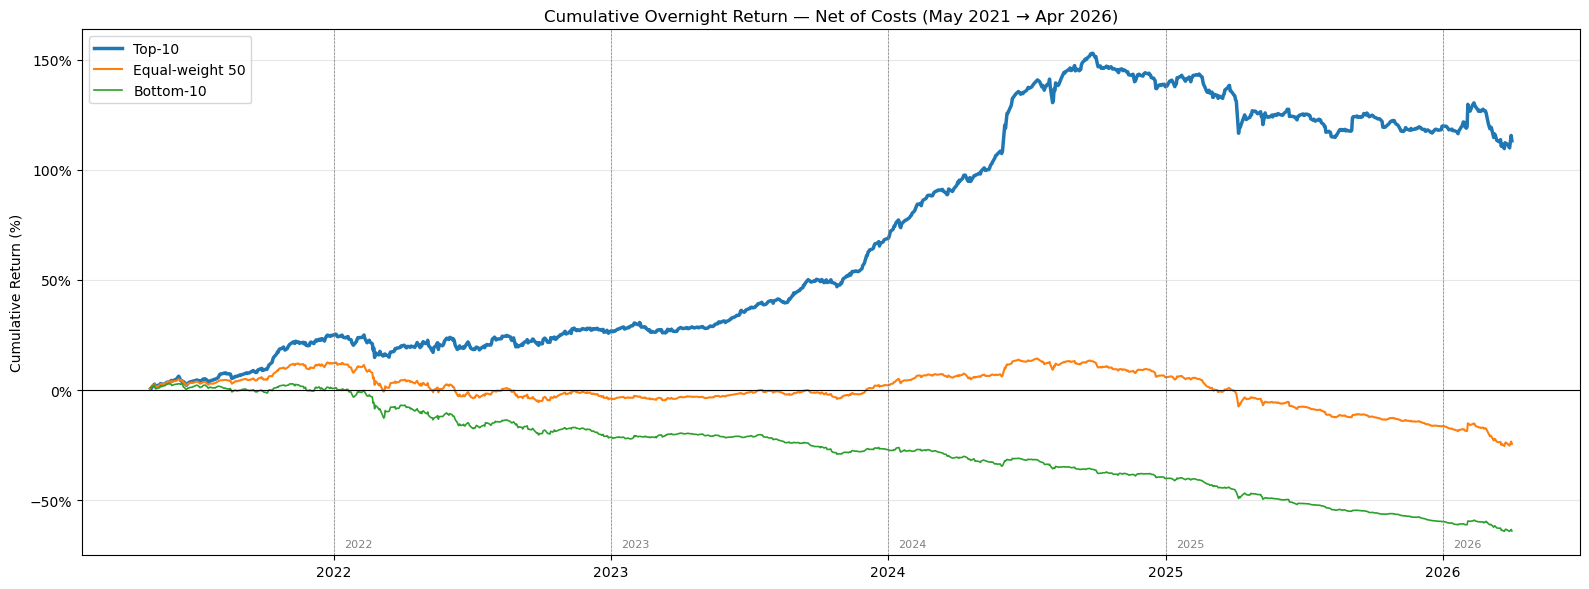

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))
for s, color, lw in [
    (ret_top,   'darkgreen', 2.5),
    (ret_bench, 'steelblue', 1.5),
    (ret_bot,   'red',       1.2),
]:
    cum = (1 + s.dropna()).cumprod() - 1
    ax.plot(cum.index, cum * 100, label=s.name, linewidth=lw)

ax.axhline(0, color='black', linewidth=0.8)

# Year dividers
for yr in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')
    ax.text(pd.Timestamp(f'{yr}-01-15'), ax.get_ylim()[0] * 0.95,
            str(yr), fontsize=8, color='grey')

ax.set_title('Cumulative Overnight Return — Net of Costs (May 2021 → Apr 2026)')
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend()
plt.tight_layout()
plt.show()

## Overall Performance Table

In [5]:
rows = [
    metrics(ret_top,   'Top-10 Strategy'),
    metrics(ret_bench, 'Equal-weight all 50'),
    metrics(ret_bot,   'Bottom-10'),
]
display(pd.DataFrame(rows).set_index('Label'))

edge = (1 + ret_top.mean())**250 - 1 - ((1 + ret_bench.mean())**250 - 1)
spread = (1 + ret_top.mean())**250 - 1 - ((1 + ret_bot.mean())**250 - 1)
print(f'\nEdge over equal-weight benchmark: {edge:+.1%} annualised')
print(f'Top-10 vs Bottom-10 spread:       {spread:+.1%} annualised')

,Sessions,Net/session,Ann. return,Sharpe,Max drawdown,Win rate
Label,,,,,,
Top-10 Strategy,1220,0.0640%,17.4%,1.62,-17.1%,59.7%
Equal-weight all 50,1221,-0.0215%,-5.2%,-0.63,-34.8%,52.1%
Bottom-10,1220,-0.0819%,-18.5%,-2.21,-65.3%,44.0%



Edge over equal-weight benchmark: +22.6% annualised
Top-10 vs Bottom-10 spread:       +35.9% annualised


## Year-by-Year Breakdown

This is the most important table — shows whether the strategy worked consistently across different market conditions.

In [6]:
years = sorted(ret_top.index.year.unique())
yr_rows = []

for yr in years:
    s   = str(yr) + '-01-01'
    e   = str(yr) + '-12-31'
    top = run_backtest(scores_df, overnight_df, s, e)
    bot = run_bottom  (scores_df, overnight_df, s, e)
    bnc = run_benchmark(overnight_df, s, e)

    if len(top) < 10: continue   # skip partial years with too few sessions

    def ann(x): return (1 + x.mean())**250 - 1 if len(x) > 0 else np.nan
    def mdd(x):
        c = (1 + x.dropna()).cumprod()
        return (c / c.cummax() - 1).min()
    def wr(x): return (x > 0).mean()

    yr_rows.append({
        'Year':           yr,
        'Sessions':       len(top),
        'Top-10 (net)':   f'{ann(top):+.1%}',
        'Benchmark (net)':f'{ann(bnc):+.1%}',
        'Bottom-10 (net)':f'{ann(bot):+.1%}',
        'Edge vs bench':  f'{ann(top)-ann(bnc):+.1%}',
        'Max DD':         f'{mdd(top):.1%}',
        'Win rate':       f'{wr(top):.1%}',
    })

yr_df = pd.DataFrame(yr_rows).set_index('Year')
display(yr_df)

# How many years did top-10 beat benchmark?
beat = sum(1 for r in yr_rows if float(r['Edge vs bench'].replace('%','').replace('+','')) > 0)
print(f'\nYears where Top-10 beat benchmark: {beat}/{len(yr_rows)}')

,Sessions,Top-10 (net),Benchmark (net),Bottom-10 (net),Edge vs bench,Max DD,Win rate
Year,,,,,,,
2021,166,+40.3%,+12.1%,+1.3%,+28.1%,-3.9%,69.3%
2022,248,+1.7%,-13.9%,-21.7%,+15.7%,-8.5%,55.2%
2023,246,+34.4%,+6.6%,-6.9%,+27.8%,-3.7%,67.1%
2024,249,+42.2%,+4.0%,-17.9%,+38.2%,-6.4%,66.7%
2025,249,-7.2%,-20.9%,-32.6%,+13.6%,-11.8%,49.0%
2026,62,-10.6%,-32.8%,-35.1%,+22.2%,-9.0%,37.1%



Years where Top-10 beat benchmark: 6/6


## Monthly Return Heatmap — All Years

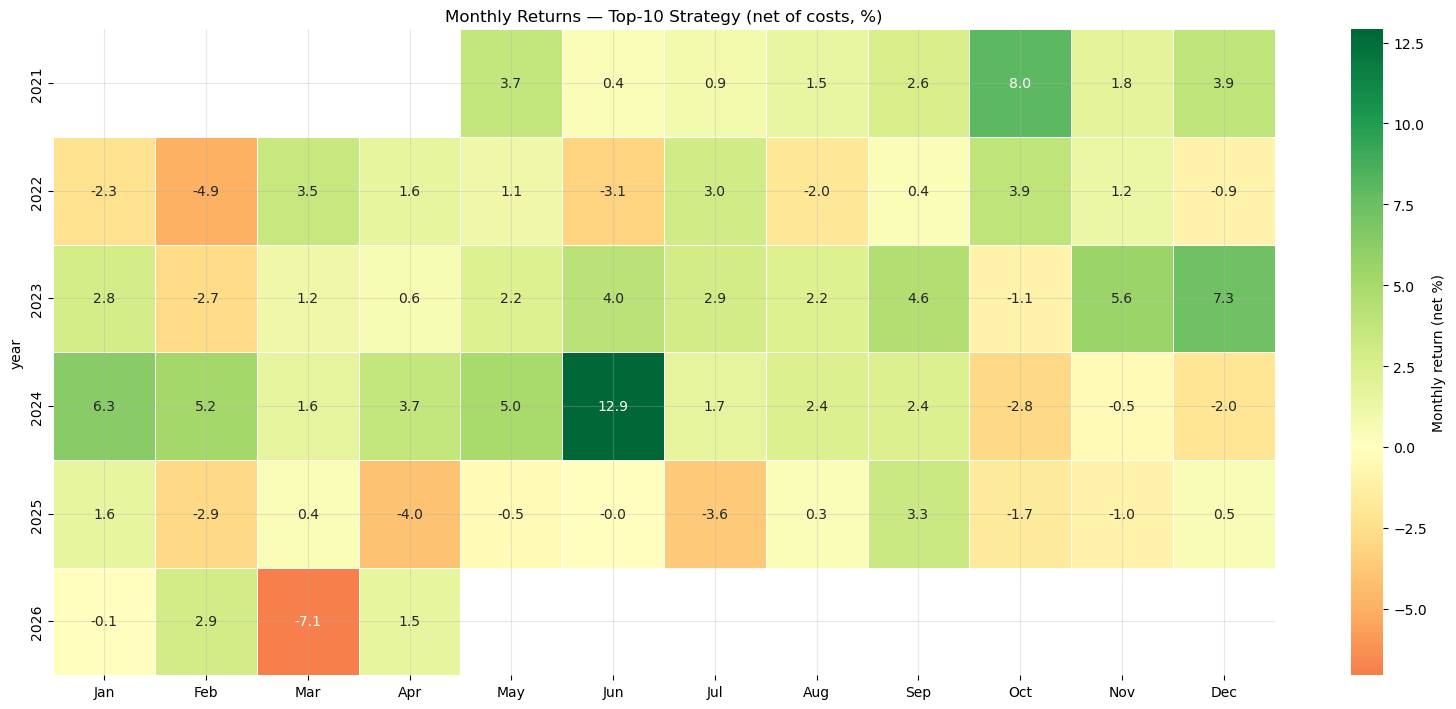

Positive months: 41/60 (68%)


In [7]:
monthly = ret_top.resample('ME').apply(lambda x: (1 + x).prod() - 1)
pivot = monthly.to_frame('r')
pivot['year']  = pivot.index.year
pivot['month'] = pivot.index.month
heat = pivot.pivot(index='year', columns='month', values='r')
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'][:len(heat.columns)]

fig, ax = plt.subplots(figsize=(16, max(4, len(heat) * 1.2)))
sns.heatmap(
    heat * 100,
    cmap='RdYlGn', center=0,
    annot=True, fmt='.1f',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Monthly return (net %)'}
)
ax.set_title('Monthly Returns — Top-10 Strategy (net of costs, %)')
plt.tight_layout()
plt.show()

pos_months = (heat > 0).sum().sum()
total_months = heat.notna().sum().sum()
print(f'Positive months: {pos_months}/{total_months} ({pos_months/total_months:.0%})')

## Drawdown Chart

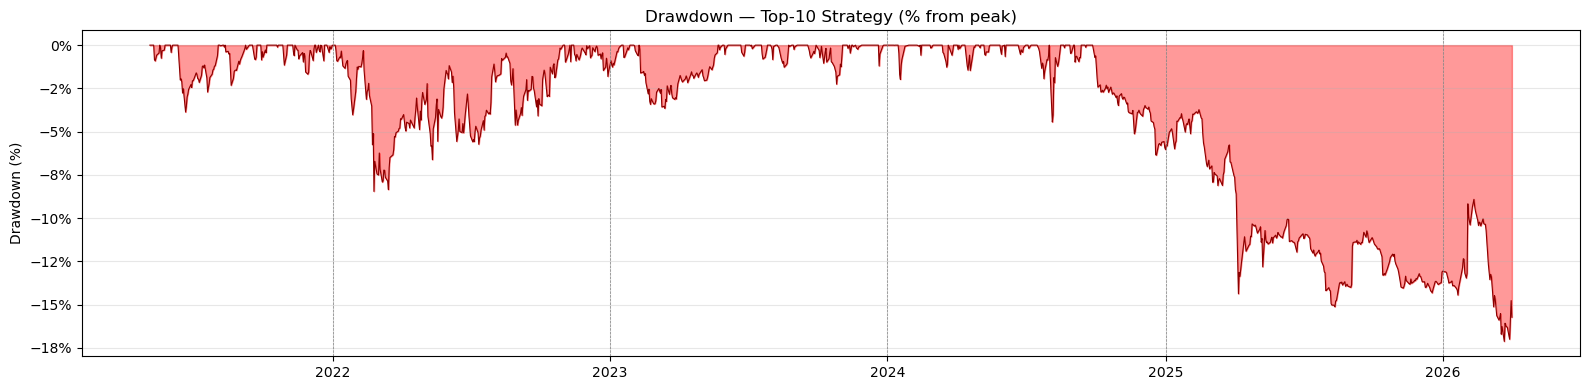

Worst drawdown: -17.1% on 2026-03-23


In [8]:
cum = (1 + ret_top.dropna()).cumprod()
dd  = (cum / cum.cummax() - 1) * 100

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(dd.index, dd, 0, color='red', alpha=0.4)
ax.plot(dd.index, dd, color='darkred', linewidth=0.8)
ax.set_title('Drawdown — Top-10 Strategy (% from peak)')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for yr in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

worst_dd = dd.min()
worst_dd_date = dd.idxmin()
print(f'Worst drawdown: {worst_dd:.1f}% on {worst_dd_date.date()}')

## Rolling 60-Session Performance

Shows whether the edge is stable over time or concentrated in specific periods.

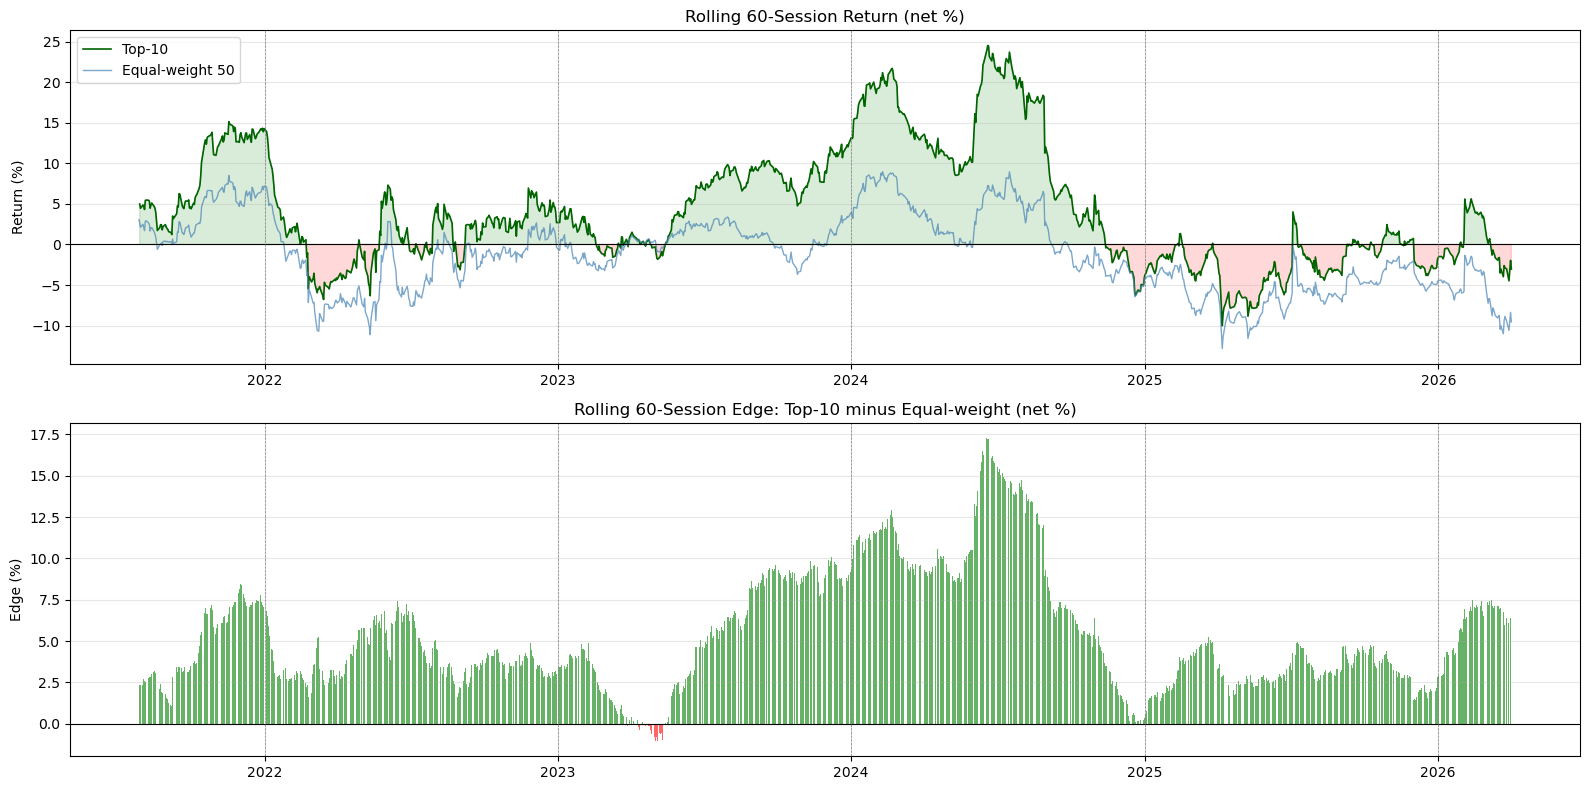

Sessions where Top-10 outperformed benchmark (rolling 60): 97.9%


In [9]:
roll_ret = ret_top.rolling(60).apply(lambda x: (1+x).prod()-1, raw=False)
roll_bnc = ret_bench.rolling(60).apply(lambda x: (1+x).prod()-1, raw=False)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(roll_ret.index, roll_ret * 100, color='darkgreen', linewidth=1.2, label='Top-10')
axes[0].plot(roll_bnc.index, roll_bnc * 100, color='steelblue', linewidth=1.0, label='Equal-weight 50', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].fill_between(roll_ret.index, roll_ret*100, 0,
                     where=(roll_ret > 0), alpha=0.15, color='green')
axes[0].fill_between(roll_ret.index, roll_ret*100, 0,
                     where=(roll_ret < 0), alpha=0.15, color='red')
axes[0].set_title('Rolling 60-Session Return (net %)')
axes[0].set_ylabel('Return (%)')
axes[0].legend()

roll_edge = roll_ret - roll_bnc
axes[1].bar(roll_edge.index, roll_edge * 100,
            color=['green' if v > 0 else 'red' for v in roll_edge],
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Rolling 60-Session Edge: Top-10 minus Equal-weight (net %)')
axes[1].set_ylabel('Edge (%)')

for ax in axes:
    for yr in range(2022, 2027):
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

pct_positive_edge = (roll_edge.dropna() > 0).mean()
print(f'Sessions where Top-10 outperformed benchmark (rolling 60): {pct_positive_edge:.1%}')